In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from adjustText import adjust_text

from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

from util import *


EXT='pdf'
DPI=400

In [2]:
models = list_models()
models

['gooey', 'neongooey', 'proteus', 'pacman', 'lincs', 'moai', 'planatmo']

In [3]:
models_data = {}
for m in models:
    models_data[m] = load_model_data(m, quiet=True)

Loading model gooey
Loading model neongooey
Loading model proteus
Loading model pacman
Loading model lincs
Loading model moai
Loading model planatmo


In [4]:
planets = list_planets()
planets

('earth', 'venus')

In [5]:
print(", ".join(models_data["proteus"]["earth"]["Hhigh-Chigh-evo"].keys()))

t(yr), T_surf(K), T_pot(K), flux_surf(W/m2), flux_OLR(W/m2), flux_ASR(W/m2), phi(vol_frac), fO2_melt(bar), fO2_solid(bar), thick_surf_bl(m), massC_solid(kg), massC_melt(kg), massC_atm(kg), massH_solid(kg), massH_melt(kg), massH_atm(kg), massO_atm(kg), p_surf(bar), p_H2O(bar), p_CO2(bar), p_CO(bar), p_H2(bar), p_CH4(bar), p_O2(bar), mmw(kg/mol), R_trans(m), R_solid(m), viscosity(Pa.s), phi(mass_frac), p_SO2(bar), p_NH3(bar), p_N2(bar), p_H2S(bar), p_S2(bar)


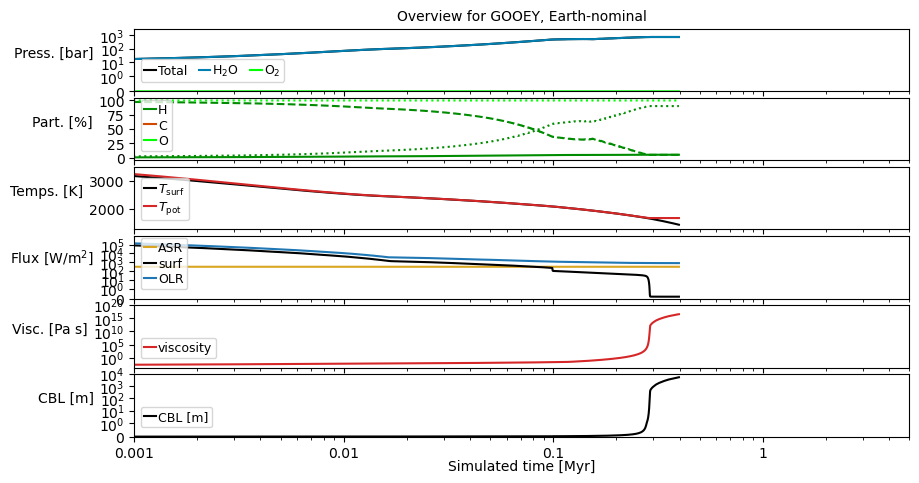

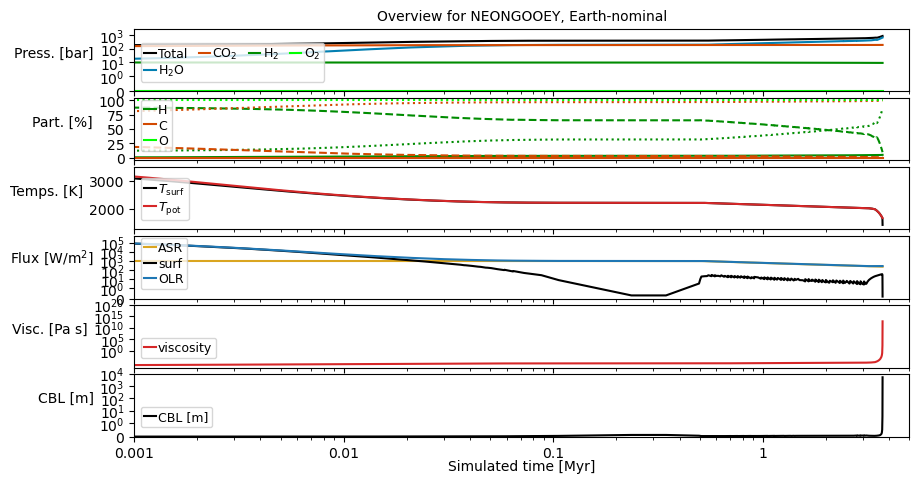

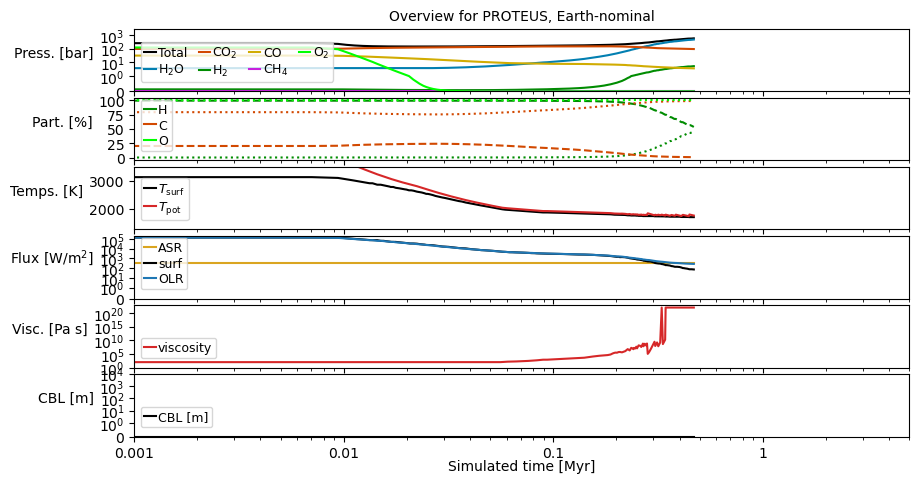

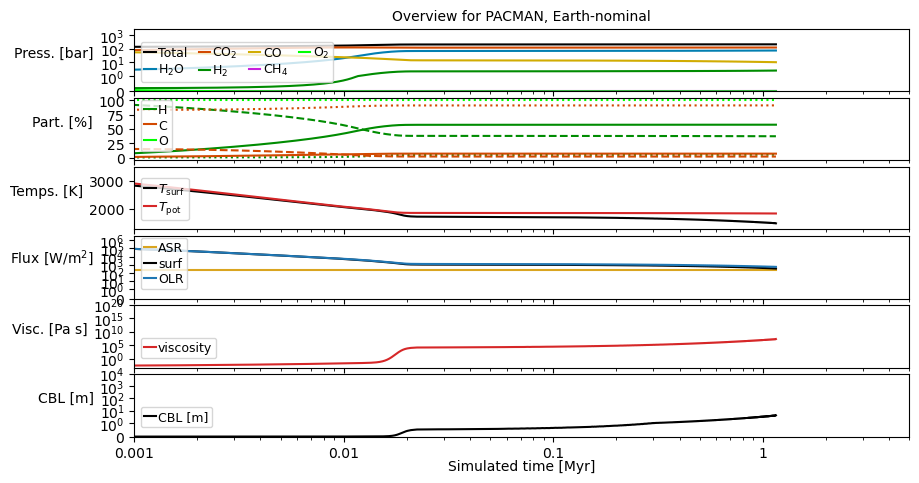

/tmp/ipykernel_4284/3605312397.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(loc="lower left", bbox_to_anchor=(0.0, 0.05), ncol=ncol,


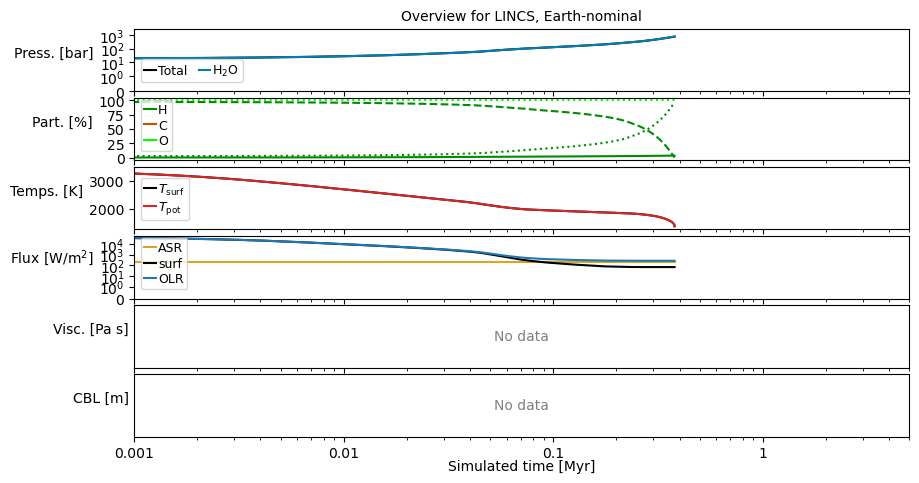

/tmp/ipykernel_4284/3605312397.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(loc="lower left", bbox_to_anchor=(0.0, 0.05), ncol=ncol,


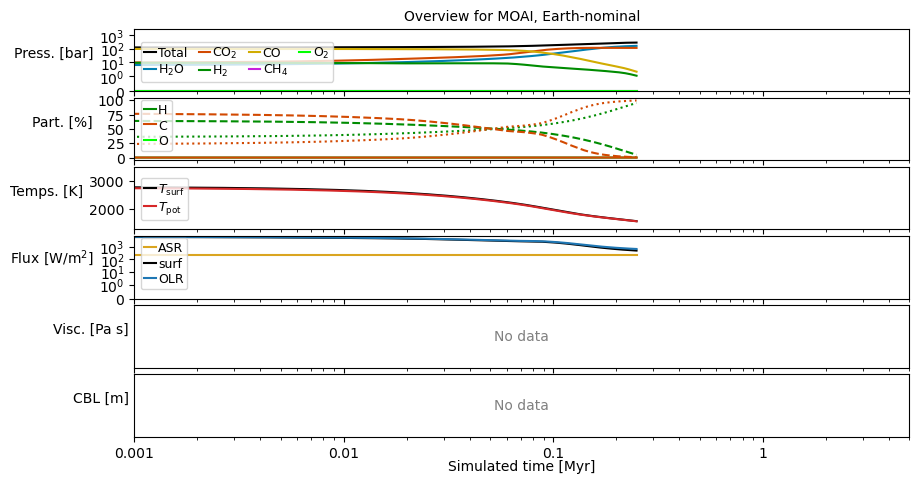

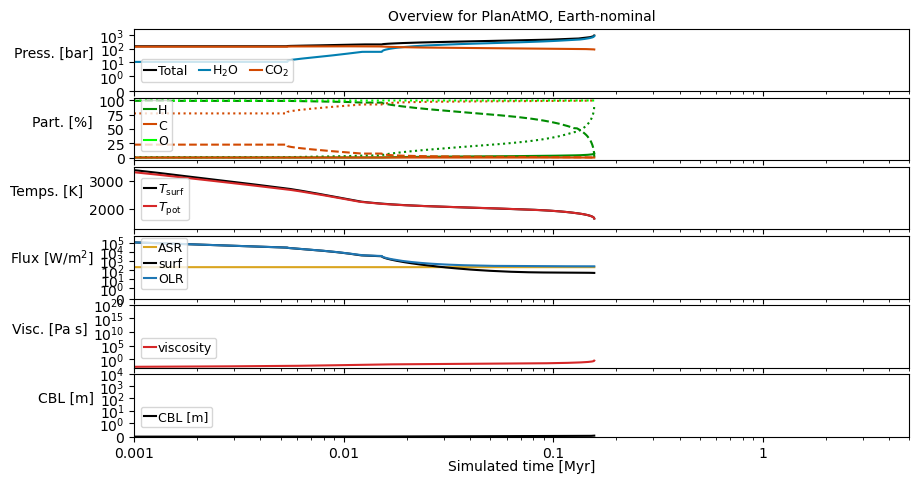

In [6]:
def plot_overview(model, planet, case):

    Nax = 6
    fig,axs = plt.subplots(Nax,1, figsize=(10,0.5+0.8*Nax), sharex=True)

    dat = models_data[model][planet][case+"-evo"]
    x = dat["t(yr)"]/1e6

    # Surface pressure
    ax = axs[0]
    ax.plot(x, dat["p_surf(bar)"], label="Total", color="k")
    for gas in chili_gases:
        y = dat[f"p_{gas}(bar)"]
        if np.any(y > 0):
            ax.plot(x, y, label=get_label(gas), color=get_color(gas))
    ax.set_yscale("symlog", linthresh=1)
    ax.set_ylabel("Press. [bar]", rotation=0, ha='right')
    ax.set_ylim(bottom=0, top=3e3)

    # Partitioning
    ax = axs[1]
    for elem in ["H", "C", "O"]:
        ax.plot([],[], color=get_color(elem), ls='solid', label=f"{elem}")

        tot = np.zeros_like(x)
        for res in ["atm", "melt", "solid"]:
            key = f"mass{elem}_{res}(kg)"
            if key not in dat:
                dat[key] = np.zeros_like(x)
            tot += dat[key]

        for res in ["atm", "melt", "solid"]:
            key = f"mass{elem}_{res}(kg)"
            y = 100*dat[key]/tot
            if np.any(y > 0):
                ax.plot(x, y, color=get_color(elem), ls={'atm':'dotted', 'melt':'dashed', 'solid':'solid'}[res])
    ax.set_ylabel("Part. [%]", rotation=0, ha='right')
    ax.set_yticks([0, 25, 50, 75, 100])

    # Temperatures
    ax = axs[2]
    ax.plot(x, dat["T_surf(K)"], c='black',   label=r"$T_{\rm surf}$")
    ax.plot(x, dat["T_pot(K)"],  c='tab:red', label=r"$T_{\rm pot}$")
    ax.set_ylabel("Temps. [K]", rotation=0, ha='right')
    ax.set_ylim(bottom=1250, top=3500)

    # Fluxes
    ax = axs[3]
    ax.plot(x, dat["flux_ASR(W/m2)"],   c='goldenrod', label="ASR")
    ax.plot(x, dat["flux_surf(W/m2)"],  c='black', label="surf")
    ax.plot(x, dat["flux_OLR(W/m2)"],   c='tab:blue', label="OLR")
    ax.set_yscale("symlog", linthresh=1)
    ax.set_ylabel("Flux [W/m$^2$]", rotation=0, ha='right')
    ax.set_ylim(bottom=0)

    # Viscosity
    y = dat["viscosity(Pa.s)"]
    ax = axs[4]
    ax.set_ylabel("Visc. [Pa s]", rotation=0, ha='right')
    if np.any(y > 0):
        ax.plot(x, y, c='tab:red', label="viscosity")
        ax.set_yscale("log")
        ax.set_yticks([1, 1e5, 1e10, 1e15, 1e20])

    # Skin thickness
    y = dat["thick_surf_bl(m)"] 
    ax = axs[5]
    ax.set_ylabel("CBL [m]", rotation=0, ha='right')
    if np.any(y > 0):
        ax.plot(x, y, c='k', label="CBL [m]")
        ax.set_yscale("symlog", linthresh=1)
        ax.set_ylim(bottom=0, top=1e4)

    
    for iax,ax in enumerate(axs):
        if iax == 0:
            ncol = 4
        else:
            ncol = 1

        leg = ax.legend(loc="lower left", bbox_to_anchor=(0.0, 0.05), ncol=ncol,
                  fontsize=9, handletextpad=0.2, columnspacing=0.9, handlelength=0.9, labelspacing=0.2, borderpad=0.3,
                  frameon=True)
        
        # if legend is empty
        if leg.get_texts() == []:
            leg.remove()
            ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes, fontsize=10, color='gray')
            ax.set_yticks([])

    axs[-1].set_xlabel("Simulated time [Myr]", labelpad=-1)
    axs[-1].set_xscale("log")
    axs[-1].set_xlim(left=1e-3, right=5)
    axs[-1].xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%g"))

    fig.subplots_adjust(hspace=0.1)

    title = "Overview for " + get_label(model) + ", " + get_label(planet) + "-" + case
    axs[0].set_title(title, fontsize=10)


    plt.show()
    fig.savefig(f"out/overview_{model}_{planet}_{case}.{EXT}", bbox_inches='tight', dpi=DPI, pad_inches=0.03)


for model in models:
    plot_overview(model, "earth", "nominal")